In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
uploaded = files.upload()

Saving water_dataX.csv to water_dataX.csv


In [3]:
df = pd.read_csv("water_dataX.csv", encoding='latin-1')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset Shape: (1991, 12)

Columns:
['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (µmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']


,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   STATION CODE                      1991 non-null   object
 1   LOCATIONS                         1991 non-null   object
 2   STATE                             1991 non-null   object
 3   Temp                              1991 non-null   object
 4   D.O. (mg/l)                       1991 non-null   object
 5   PH                                1991 non-null   object
 6   CONDUCTIVITY (µmhos/cm)           1991 non-null   object
 7   B.O.D. (mg/l)                     1991 non-null   object
 8   NITRATENAN N+ NITRITENANN (mg/l)  1991 non-null   object
 9   FECAL COLIFORM (MPN/100ml)        1991 non-null   object
 10  TOTAL COLIFORM (MPN/100ml)Mean    1991 non-null   object
 11  year                              1991 non-null   int64 
dtypes: int64(1), object(

In [6]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


,0
STATION CODE,0
LOCATIONS,0
STATE,0
Temp,0
D.O. (mg/l),0
PH,0
CONDUCTIVITY (µmhos/cm),0
B.O.D. (mg/l),0
NITRATENAN N+ NITRITENANN (mg/l),0
FECAL COLIFORM (MPN/100ml),0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [8]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1990, 12)


In [9]:
for column in df.columns:
    print(column)

STATION CODE
LOCATIONS
STATE
Temp
D.O. (mg/l)
PH
CONDUCTIVITY (µmhos/cm)
B.O.D. (mg/l)
NITRATENAN N+ NITRITENANN (mg/l)
FECAL COLIFORM (MPN/100ml)
TOTAL COLIFORM (MPN/100ml)Mean
year


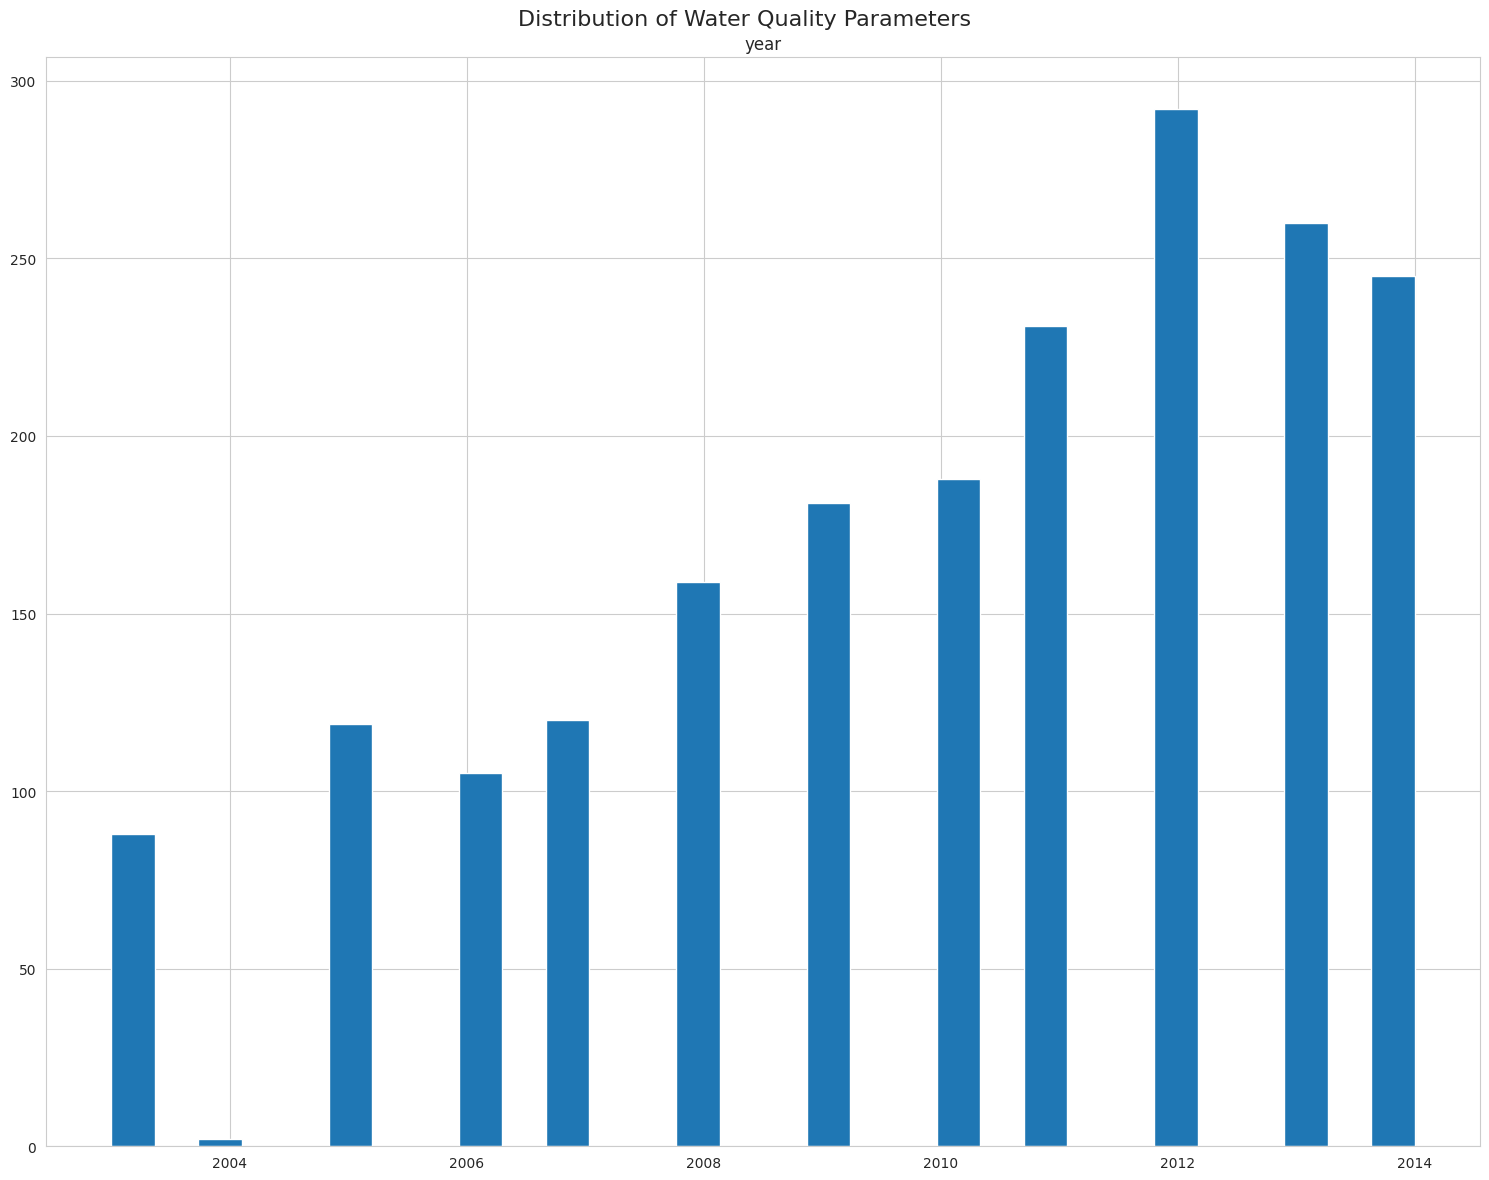

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Water Quality Parameters", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
print(df.columns.tolist())

['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (µmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']


In [12]:
df = df.rename(columns={
    'STATION CODE': 'Station_Code',
    'LOCATIONS': 'Location',
    'STATE': 'State',
    'Temp': 'Temperature',
    'D.O. (mg/l)': 'DO',
    'PH': 'pH',
    'CONDUCTIVITY (µmhos/cm)': 'Conductivity',
    'B.O.D. (mg/l)': 'BOD',
    'NITRATENAN N+ NITRITENANN (mg/l)': 'Nitrate_Nitrite',
    'FECAL COLIFORM (MPN/100ml)': 'Fecal_Coliform',
    'TOTAL COLIFORM (MPN/100ml)Mean': 'Total_Coliform',
    'year': 'Year'
})

print(df.columns.tolist())

['Station_Code', 'Location', 'State', 'Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'Year']


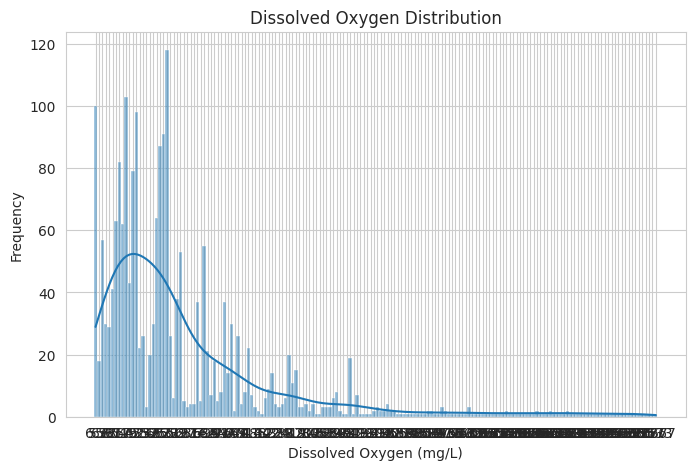

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='DO',
    kde=True
)

plt.title("Dissolved Oxygen Distribution")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Frequency")

plt.show()

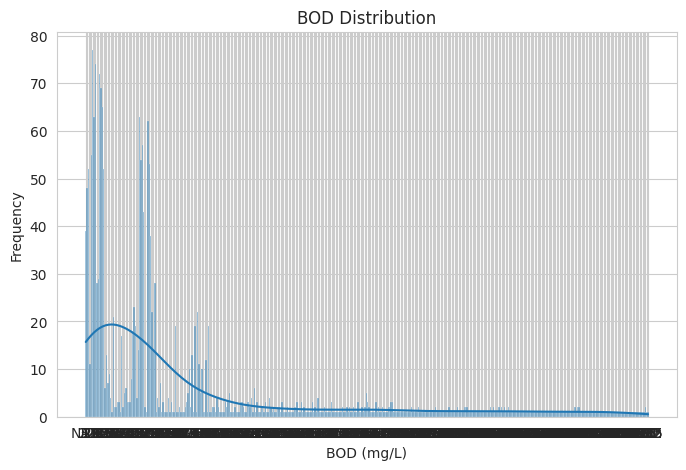

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='BOD',
    kde=True
)

plt.title("BOD Distribution")
plt.xlabel("BOD (mg/L)")
plt.ylabel("Frequency")

plt.show()

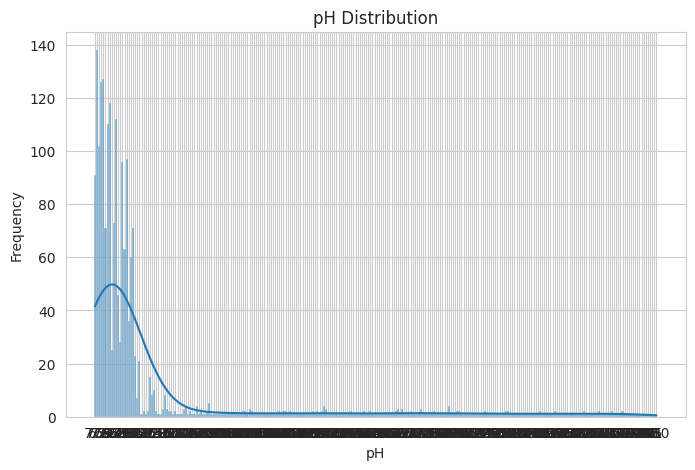

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='pH',
    kde=True
)

plt.title("pH Distribution")
plt.xlabel("pH")
plt.ylabel("Frequency")

plt.show()

In [16]:
def calculate_quality_score(row):

    score = 0

    # pH
    if 6.5 <= row['pH'] <= 8.5:
        score += 1

    # Dissolved Oxygen
    if row['DO'] >= 5:
        score += 1

    # BOD
    if row['BOD'] <= 3:
        score += 1

    # Nitrate + Nitrite
    if row['Nitrate_Nitrite'] <= 10:
        score += 1

    # Fecal Coliform
    if row['Fecal_Coliform'] <= 100:
        score += 1

    # Total Coliform
    if row['Total_Coliform'] <= 500:
        score += 1

    return score

In [17]:
numeric_cols = [
    'Temperature', 'DO', 'pH', 'Conductivity', 'BOD',
    'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert numeric columns to numeric values
numeric_cols = [
    'Temperature',
    'DO',
    'pH',
    'Conductivity',
    'BOD',
    'Nitrate_Nitrite',
    'Fecal_Coliform',
    'Total_Coliform'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check missing values
print("Missing values before imputation:")
print(df[numeric_cols].isnull().sum())

# Use median values for missing measurements
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after imputation:")
print(df[numeric_cols].isnull().sum())

df['Quality_Score'] = df.apply(
    calculate_quality_score,
    axis=1
)

display(
    df[['Quality_Score']].head(10)
)

Missing values before imputation:
Temperature         91
DO                  30
pH                   7
Conductivity        24
BOD                 42
Nitrate_Nitrite    224
Fecal_Coliform     315
Total_Coliform     131
dtype: int64

Missing values after imputation:
Temperature        0
DO                 0
pH                 0
Conductivity       0
BOD                0
Nitrate_Nitrite    0
Fecal_Coliform     0
Total_Coliform     0
dtype: int64


,Quality_Score
0,6
1,4
2,4
3,3
4,4
5,4
6,4
7,4
8,4
9,4


In [18]:
def classify_water(score):

    if score >= 5:
        return 'Good'
    elif score >= 3:
        return 'Moderate'
    else:
        return 'Poor'


df['Water_Quality'] = df['Quality_Score'].apply(
    classify_water
)

print(df['Water_Quality'].value_counts())

Water_Quality
Moderate    995
Good        856
Poor        139
Name: count, dtype: int64


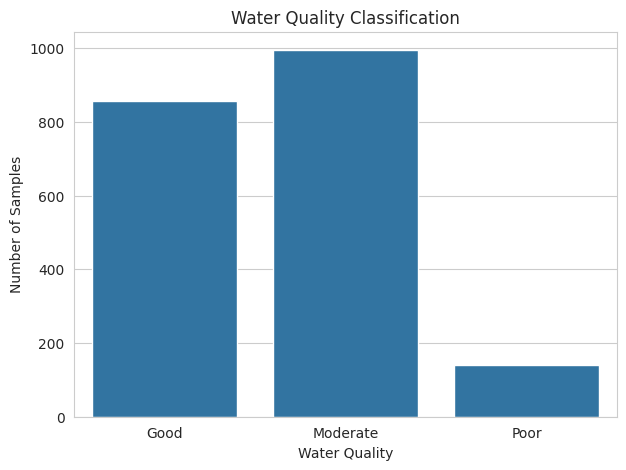

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Water_Quality',
    order=['Good', 'Moderate', 'Poor']
)

plt.title("Water Quality Classification")
plt.xlabel("Water Quality")
plt.ylabel("Number of Samples")

plt.show()

In [44]:
# Standardize state names

state_mapping = {
    'TAMIL NADU': 'TAMILNADU',
    'TRIPURA': 'TRIPURA',
    'ORISSA': 'ODISHA',
    'PONDICHERRY': 'PUDUCHERRY',
    'DAMAN, DIU, DADRA NAGAR HAVELI': 'DAMAN & DIU',
    'NAN': np.nan
}

df['State_Clean'] = df['State'].astype(str).str.strip().str.upper()

# Apply known corrections
df['State_Clean'] = df['State_Clean'].replace(state_mapping)

print(df['State_Clean'].value_counts().head(25))
print("Missing/unknown states:", df['State_Clean'].isna().sum())

State_Clean
KERALA                                              275
MAHARASHTRA                                         142
MEGHALAYA                                           125
GOA                                                 101
MANIPUR                                              76
PUNJAB                                               48
TAMILNADU                                            44
ODISHA                                               40
GUJARAT                                              37
DAMAN & DIU                                          20
MIZORAM                                              20
PUDUCHERRY                                           20
RAJASTHAN                                            20
HARYANA                                              18
HIMACHAL PRADESH                                     16
KARNATAKA                                            16
TRIPURA                                              15
ANDHRA PRADESH                      

In [45]:
# List of states/UTs expected in the dataset
valid_states = [
    'ANDHRA PRADESH',
    'ARUNACHAL PRADESH',
    'ASSAM',
    'BIHAR',
    'CHHATTISGARH',
    'GOA',
    'GUJARAT',
    'HARYANA',
    'HIMACHAL PRADESH',
    'JHARKHAND',
    'KARNATAKA',
    'KERALA',
    'MADHYA PRADESH',
    'MAHARASHTRA',
    'MANIPUR',
    'MEGHALAYA',
    'MIZORAM',
    'NAGALAND',
    'ODISHA',
    'PUNJAB',
    'RAJASTHAN',
    'SIKKIM',
    'TAMILNADU',
    'TELANGANA',
    'TRIPURA',
    'UTTAR PRADESH',
    'UTTARAKHAND',
    'WEST BENGAL',
    'PUDUCHERRY',
    'DAMAN & DIU'
]

def extract_state_from_location(row):
    current_state = row['State_Clean']
    location = str(row['Location']).upper()

    # If already a valid state, keep it
    if current_state in valid_states:
        return current_state

    # Otherwise search the location for a known state
    for state in valid_states:
        if state in location:
            return state

    return np.nan

df['State_Clean'] = df.apply(extract_state_from_location, axis=1)

print(df['State_Clean'].value_counts())
print("\nRemaining unknown states:", df['State_Clean'].isna().sum())

State_Clean
KERALA              414
MAHARASHTRA         177
MEGHALAYA           148
GOA                 146
MANIPUR             118
PUNJAB              107
TAMILNADU            84
GUJARAT              75
ODISHA               40
HARYANA              35
TRIPURA              27
RAJASTHAN            26
MIZORAM              24
KARNATAKA            21
DAMAN & DIU          20
PUDUCHERRY           20
HIMACHAL PRADESH     16
ANDHRA PRADESH       14
MADHYA PRADESH        2
Name: count, dtype: int64

Remaining unknown states: 476


In [46]:
# Count samples for each cleaned state
state_counts = df['State_Clean'].value_counts()

# Keep states with at least 20 samples
valid_states = state_counts[state_counts >= 20].index

print("States included in analysis:")
print(valid_states)

print("\nNumber of states:", len(valid_states))

States included in analysis:
Index(['KERALA', 'MAHARASHTRA', 'MEGHALAYA', 'GOA', 'MANIPUR', 'PUNJAB',
       'TAMILNADU', 'GUJARAT', 'ODISHA', 'HARYANA', 'TRIPURA', 'RAJASTHAN',
       'MIZORAM', 'KARNATAKA', 'DAMAN & DIU', 'PUDUCHERRY'],
      dtype='object', name='State_Clean')

Number of states: 16


In [47]:
state_quality_final = pd.crosstab(
    df.loc[df['State_Clean'].isin(valid_states), 'State_Clean'],
    df.loc[df['State_Clean'].isin(valid_states), 'Water_Quality'],
    normalize='index'
) * 100

# Make sure all quality categories exist
for col in ['Good', 'Moderate', 'Poor']:
    if col not in state_quality_final.columns:
        state_quality_final[col] = 0

state_quality_final = state_quality_final[
    ['Good', 'Moderate', 'Poor']
]

display(state_quality_final.round(2))

Water_Quality,Good,Moderate,Poor
State_Clean,,,
DAMAN & DIU,50.00,40.00,10.00
GOA,28.08,69.86,2.05
GUJARAT,34.67,44.00,21.33
HARYANA,11.43,77.14,11.43
KARNATAKA,57.14,42.86,0.00
KERALA,26.33,71.50,2.17
MAHARASHTRA,75.14,23.16,1.69
MANIPUR,61.86,33.90,4.24
MEGHALAYA,62.16,25.00,12.84


<Figure size 1400x700 with 0 Axes>

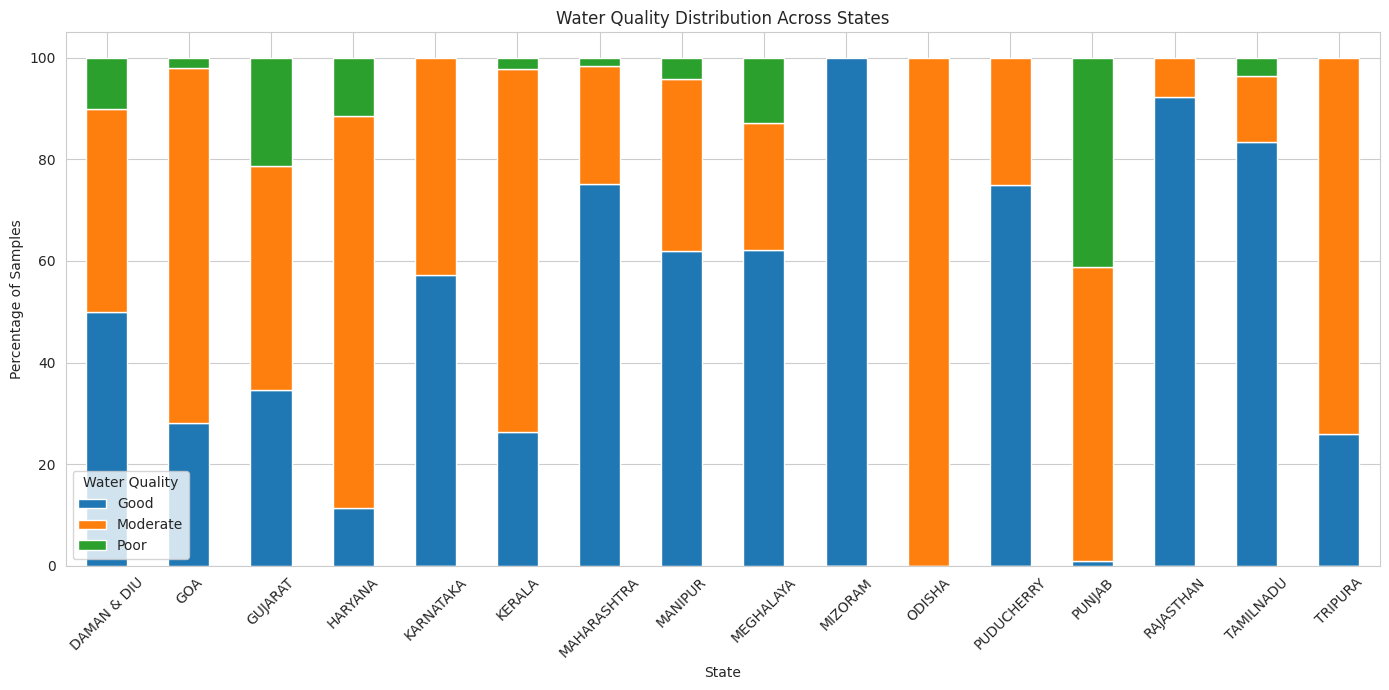

In [48]:
plt.figure(figsize=(14, 7))

state_quality_final.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title("Water Quality Distribution Across States")
plt.xlabel("State")
plt.ylabel("Percentage of Samples")
plt.legend(title="Water Quality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
df['State'] = df['State_Clean']

In [50]:
print(df['Year'].value_counts().sort_index())
print(df['Year'].unique())

Year
2003     88
2004      2
2005    119
2006    105
2007    120
2008    159
2009    181
2010    188
2011    231
2012    292
2013    260
2014    245
Name: count, dtype: int64
[2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003]


In [52]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

print(df['Year'].unique())

[2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003]


In [53]:
yearly_pollution = df.groupby('Year')[
    ['BOD', 'DO', 'Nitrate_Nitrite']
].mean()

display(yearly_pollution.round(2))

,BOD,DO,Nitrate_Nitrite
Year,,,
2003,8.77,7.19,0.50
2004,2.55,7.65,1.35
2005,11.51,6.51,1.17
2006,12.86,6.41,1.79
2007,8.19,6.36,1.13
2008,5.56,6.17,1.38
2009,6.51,6.31,2.28
2010,7.49,6.35,1.62
2011,6.31,6.23,1.34


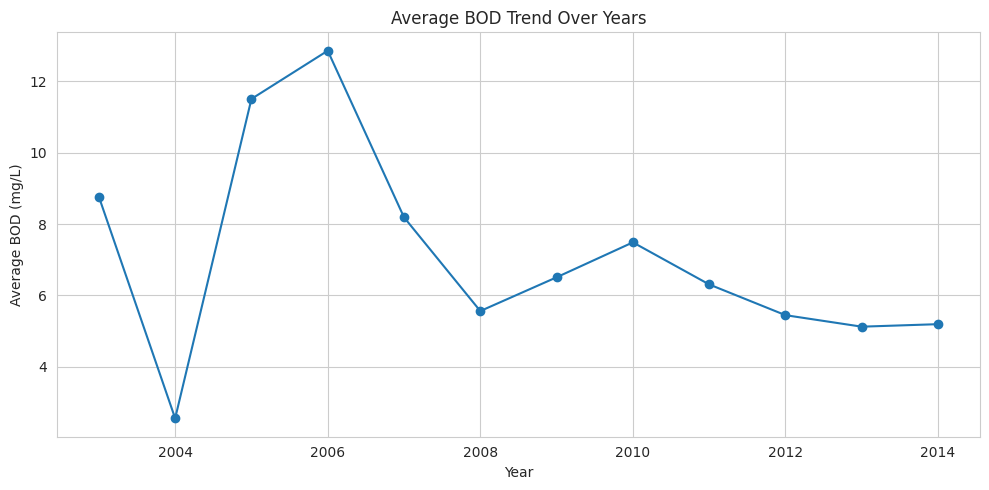

In [54]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_pollution.index,
    yearly_pollution['BOD'],
    marker='o'
)

plt.title("Average BOD Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average BOD (mg/L)")
plt.grid(True)
plt.tight_layout()
plt.show()

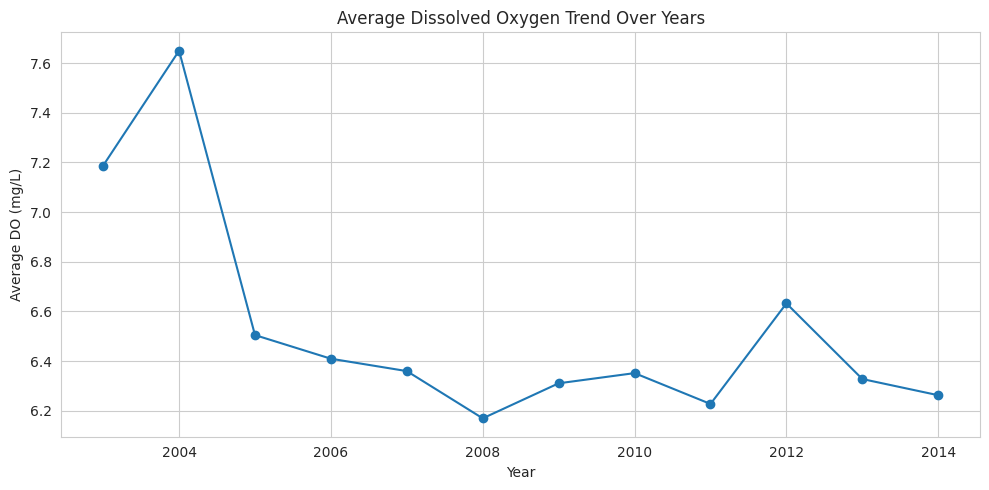

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_pollution.index,
    yearly_pollution['DO'],
    marker='o'
)

plt.title("Average Dissolved Oxygen Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average DO (mg/L)")
plt.grid(True)
plt.tight_layout()
plt.show()

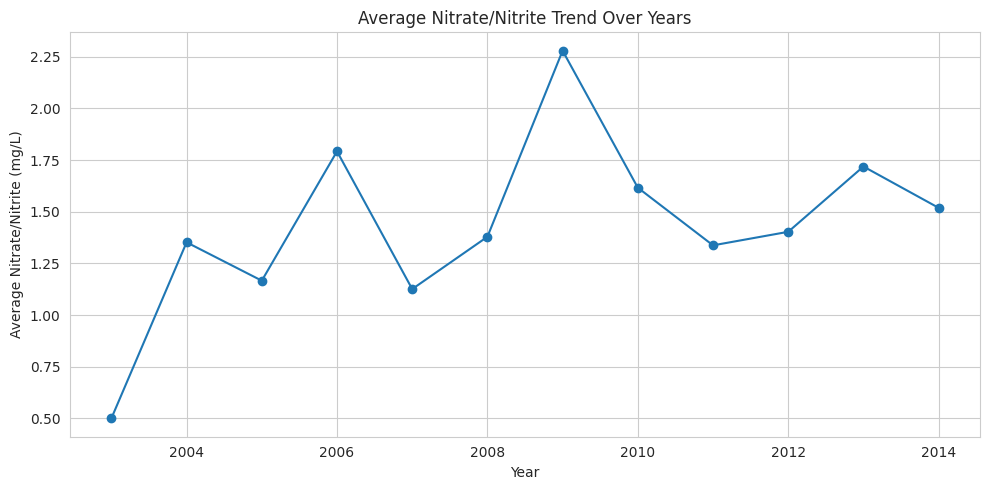

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_pollution.index,
    yearly_pollution['Nitrate_Nitrite'],
    marker='o'
)

plt.title("Average Nitrate/Nitrite Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Nitrate/Nitrite (mg/L)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
quality_parameter_means = df.groupby('Water_Quality')[
    [
        'Temperature',
        'DO',
        'pH',
        'Conductivity',
        'BOD',
        'Nitrate_Nitrite',
        'Fecal_Coliform',
        'Total_Coliform'
    ]
].mean()

display(quality_parameter_means.round(2))

,Temperature,DO,pH,Conductivity,BOD,Nitrate_Nitrite,Fecal_Coliform,Total_Coliform
Water_Quality,,,,,,,,
Good,26.16,6.88,10.43,1485.68,3.15,0.95,117.57,185.01
Moderate,26.62,6.36,111.22,1839.64,6.36,1.37,3899.51,15932.50
Poor,24.13,3.67,739.13,2981.27,32.89,5.82,4340472.34,7022838.44


In [63]:
# Check the range of important water-quality parameters

parameters = [
    'Temperature',
    'DO',
    'pH',
    'Conductivity',
    'BOD',
    'Nitrate_Nitrite',
    'Fecal_Coliform',
    'Total_Coliform'
]

range_check = df[parameters].agg(['min', 'max', 'mean', 'median'])

display(range_check.round(2))

,Temperature,DO,pH,Conductivity,BOD,Nitrate_Nitrite,Fecal_Coliform,Total_Coliform
min,10.00,0.0,0.00,0.40,0.10,0.00,0.000000e+00,0.0
max,35.00,11.4,67115.00,65700.00,534.50,108.70,2.725216e+08,511090873.0
mean,26.25,6.4,111.72,1767.13,6.83,1.50,3.051790e+05,498585.8
median,27.00,6.7,7.30,183.00,1.90,0.52,2.210000e+02,468.0


In [64]:
# Check unusual pH values

print("pH values below 0:")
print((df['pH'] < 0).sum())

print("\npH values above 14:")
print((df['pH'] > 14).sum())

print("\nHighest pH values:")
display(df[['State', 'Location', 'pH']].sort_values('pH', ascending=False).head(10))

pH values below 0:
0

pH values above 14:
89

Highest pH values:


,State,Location,pH
1920,GUJARAT,"KOLAK AT RAILWAY BRIDGE NO. 313 VAPI,VALSAD, G...",67115.0
1974,NaN,"RUSHIKULYA AT GANJAM D/S, ORISSA",28598.0
1949,KERALA,"HOSDURG, KERALA",24336.0
1913,GUJARAT,"DAMANGANGA AT KACHIGAON D\S (DAMAN),GUJARAT",21331.0
1948,KERALA,"THALIPARAMBA, KERALA",20850.0
1921,GUJARAT,AMLAKHADI AFTER CONFL. OF W. WATER FROM ANKLES...,9948.0
1929,KERALA,"CHALIYAR AT KALLAPALLY, KERALA",9416.0
1952,KERALA,"IRUPANAM, KERALA",3384.0
1935,KERALA,"PAMBA AT KALLOOPARA, KERALA",1835.0
1918,GUJARAT,"AMBIKA AT BILIMORA, GUJARAT",1708.0


In [65]:
# Identify and replace impossible pH values

invalid_ph = (df['pH'] > 14) | (df['pH'] < 0)

print("Invalid pH values found:", invalid_ph.sum())

# Replace invalid pH measurements with NaN
df.loc[invalid_ph, 'pH'] = np.nan

# Impute invalid/missing pH values with the median pH
df['pH'] = df['pH'].fillna(df['pH'].median())

print("Missing pH values after cleaning:", df['pH'].isna().sum())
print("Maximum pH after cleaning:", df['pH'].max())
print("Minimum pH after cleaning:", df['pH'].min())

Invalid pH values found: 89
Missing pH values after cleaning: 0
Maximum pH after cleaning: 9.01
Minimum pH after cleaning: 0.0


In [67]:
# Recalculate Quality Score after cleaning pH

df['Quality_Score'] = df.apply(
    calculate_quality_score,
    axis=1
)

# Recreate water quality classes
df['Water_Quality'] = df['Quality_Score'].apply(
    lambda x: 'Good' if x >= 5
    else ('Moderate' if x >= 3 else 'Poor')
)

print(df['Water_Quality'].value_counts())
print(df['Quality_Score'].value_counts().sort_index())

Water_Quality
Moderate    945
Good        912
Poor        133
Name: count, dtype: int64
Quality_Score
1     22
2    111
3    254
4    691
5    578
6    334
Name: count, dtype: int64


In [68]:
quality_parameter_means = df.groupby('Water_Quality')[
    [
        'Temperature',
        'DO',
        'pH',
        'Conductivity',
        'BOD',
        'Nitrate_Nitrite',
        'Fecal_Coliform',
        'Total_Coliform'
    ]
].mean()

display(quality_parameter_means.round(2))

,Temperature,DO,pH,Conductivity,BOD,Nitrate_Nitrite,Fecal_Coliform,Total_Coliform
Water_Quality,,,,,,,,
Good,26.18,6.90,7.28,1394.87,3.09,0.92,113.77,278.95
Moderate,26.62,6.32,7.18,1936.61,7.15,1.41,4103.93,16698.79
Poor,24.03,3.55,7.29,3115.55,30.28,6.06,4536273.15,7339481.13


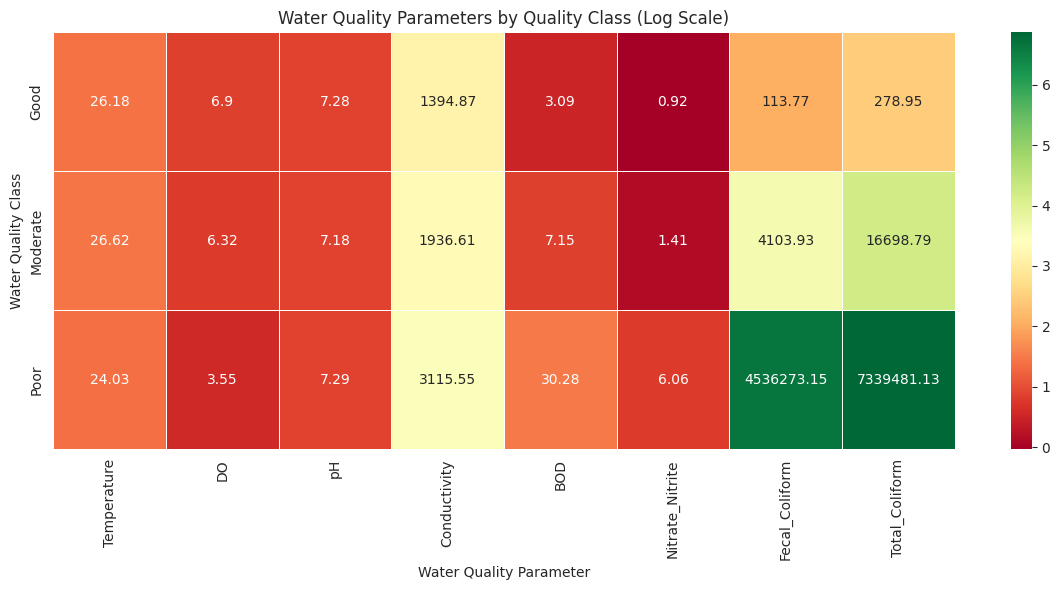

In [70]:
# Log-transformed heatmap for better visualization
log_quality_means = np.log10(
    quality_parameter_means.clip(lower=0.01)
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    log_quality_means,
    annot=quality_parameter_means.round(2),
    fmt='',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title("Water Quality Parameters by Quality Class (Log Scale)")
plt.xlabel("Water Quality Parameter")
plt.ylabel("Water Quality Class")
plt.tight_layout()
plt.show()

In [71]:
# Features for ML model

features = [
    'Temperature',
    'DO',
    'pH',
    'Conductivity',
    'BOD',
    'Nitrate_Nitrite',
    'Fecal_Coliform',
    'Total_Coliform'
]

X = df[features]
y = df['Water_Quality']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

Feature shape: (1990, 8)
Target shape: (1990,)

Class distribution:
Water_Quality
Moderate    945
Good        912
Poor        133
Name: count, dtype: int64


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1592
Testing samples: 398


In [73]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [74]:
!pip install xgboost -q

In [76]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

Class mapping:
0 = Good
1 = Moderate
2 = Poor


In [77]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_imp, y_train_encoded)

y_pred_xgb_encoded = xgb_model.predict(X_test_imp)

# Convert predictions back to original class names
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

print(y_pred_xgb[:10])

['Moderate' 'Moderate' 'Poor' 'Poor' 'Poor' 'Moderate' 'Good' 'Moderate'
 'Moderate' 'Good']


In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
----------------
Accuracy : 0.9874
Precision: 0.9875
Recall   : 0.9874
F1 Score : 0.9874

Classification Report:
              precision    recall  f1-score   support

        Good       0.98      1.00      0.99       182
    Moderate       0.99      0.98      0.99       189
        Poor       1.00      0.93      0.96        27

    accuracy                           0.99       398
   macro avg       0.99      0.97      0.98       398
weighted avg       0.99      0.99      0.99       398



In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_imp, y_train)
y_pred_log = log_model.predict(X_test_imp)


# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train_imp, y_train)
y_pred_dt = dt_model.predict(X_test_imp)


# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_imp, y_train)
y_pred_rf = rf_model.predict(X_test_imp)

print("All three models trained successfully.")

All three models trained successfully.


In [80]:
models = {
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

results = []

for model_name, predictions in models.items():
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(
            y_test, predictions, average='weighted'
        ),
        'Recall': recall_score(
            y_test, predictions, average='weighted'
        ),
        'F1 Score': f1_score(
            y_test, predictions, average='weighted'
        )
    })

model_comparison = pd.DataFrame(results)

display(
    model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7965,0.8172,0.7965,0.7905
1,Decision Tree,0.9749,0.9750,0.9749,0.9749
2,Random Forest,0.9749,0.9754,0.9749,0.9747
3,XGBoost,0.9874,0.9875,0.9874,0.9874


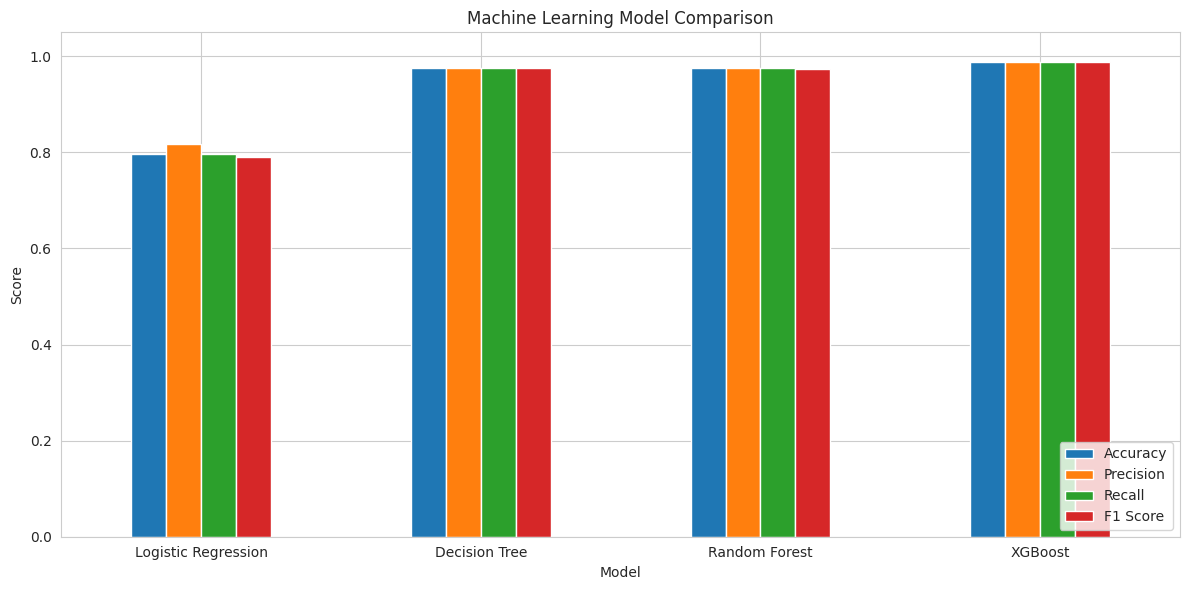

In [81]:
model_comparison.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

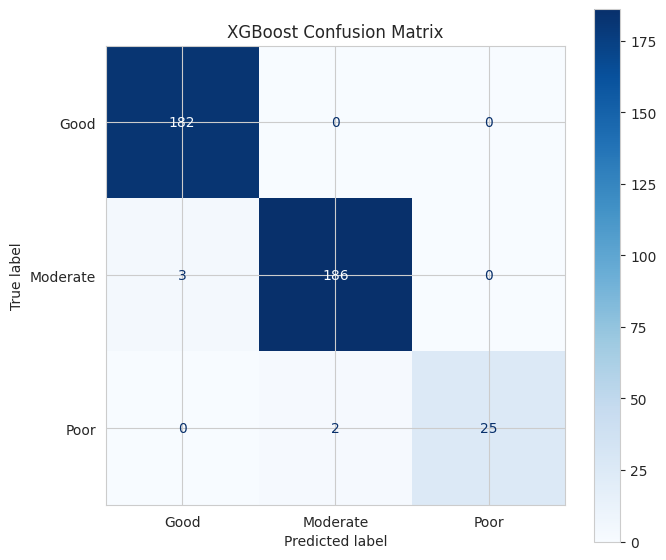

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb,
    labels=['Good', 'Moderate', 'Poor']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Good', 'Moderate', 'Poor']
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [83]:
# XGBoost Feature Importance

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
7,Total_Coliform,0.273888
6,Fecal_Coliform,0.251706
1,DO,0.179231
4,BOD,0.144960
2,pH,0.045178
5,Nitrate_Nitrite,0.042442
0,Temperature,0.033895
3,Conductivity,0.028699


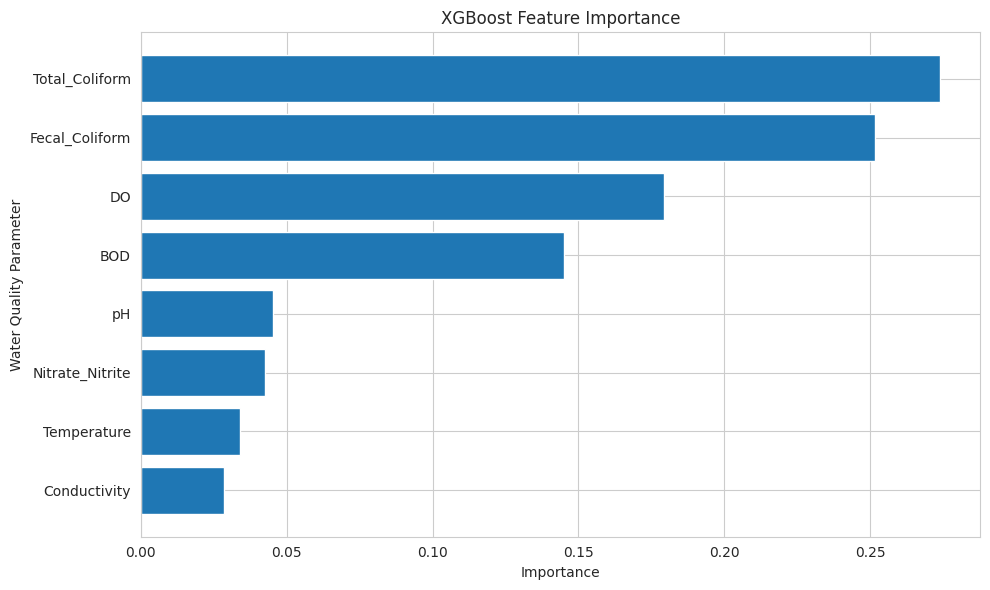

In [84]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Water Quality Parameter")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [85]:
def treatment_recommendation(row):
    recommendations = []

    if row['BOD'] > 3:
        recommendations.append(
            "Biological treatment / aeration to reduce organic pollution"
        )

    if row['DO'] < 5:
        recommendations.append(
            "Aeration to improve dissolved oxygen"
        )

    if row['pH'] < 6.5 or row['pH'] > 8.5:
        recommendations.append(
            "pH adjustment / neutralization"
        )

    if row['Fecal_Coliform'] > 100:
        recommendations.append(
            "Disinfection / chlorination to control microbial contamination"
        )

    if row['Total_Coliform'] > 500:
        recommendations.append(
            "Filtration and disinfection"
        )

    if row['Nitrate_Nitrite'] > 10:
        recommendations.append(
            "Nitrate removal treatment"
        )

    if len(recommendations) == 0:
        recommendations.append(
            "No major intervention indicated by the selected parameters"
        )

    return recommendations

In [86]:
sample = df.iloc[0]

print("Water Quality:", sample['Water_Quality'])
print("\nRecommendations:")

for recommendation in treatment_recommendation(sample):
    print("-", recommendation)

Water Quality: Good

Recommendations:
- No major intervention indicated by the selected parameters


In [87]:
def predict_water_quality(
    temperature,
    do,
    ph,
    conductivity,
    bod,
    nitrate_nitrite,
    fecal_coliform,
    total_coliform
):

    sample = pd.DataFrame([[
        temperature,
        do,
        ph,
        conductivity,
        bod,
        nitrate_nitrite,
        fecal_coliform,
        total_coliform
    ]], columns=features)

    # Impute missing values if necessary
    sample_imp = imputer.transform(sample)

    # XGBoost prediction
    prediction_encoded = xgb_model.predict(sample_imp)

    prediction = label_encoder.inverse_transform(
        prediction_encoded
    )[0]

    # Prediction probabilities
    probabilities = xgb_model.predict_proba(sample_imp)[0]

    probability_dict = dict(
        zip(label_encoder.classes_, probabilities)
    )

    # Management recommendations
    recommendations = treatment_recommendation(
        sample.iloc[0]
    )

    return prediction, probability_dict, recommendations

In [88]:
prediction, probabilities, recommendations = predict_water_quality(
    temperature=25,
    do=6,
    ph=7.2,
    conductivity=400,
    bod=2,
    nitrate_nitrite=3,
    fecal_coliform=20,
    total_coliform=100
)

print("Predicted Water Quality:", prediction)

print("\nPrediction Probabilities:")
for quality, probability in probabilities.items():
    print(f"{quality}: {probability:.2%}")

print("\nManagement Recommendations:")
for recommendation in recommendations:
    print("-", recommendation)

Predicted Water Quality: Good

Prediction Probabilities:
Good: 99.96%
Moderate: 0.03%
Poor: 0.00%

Management Recommendations:
- No major intervention indicated by the selected parameters


In [89]:
 !pip install shap -q

In [90]:
import shap
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_imp)

print(type(shap_values))

<class 'numpy.ndarray'>


In [91]:
print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test_imp.shape)
print("Number of features:", len(features))

SHAP values shape: (398, 8, 3)
Test data shape: (398, 8)
Number of features: 8


In [92]:
print("Class order:", label_encoder.classes_)

Class order: ['Good' 'Moderate' 'Poor']


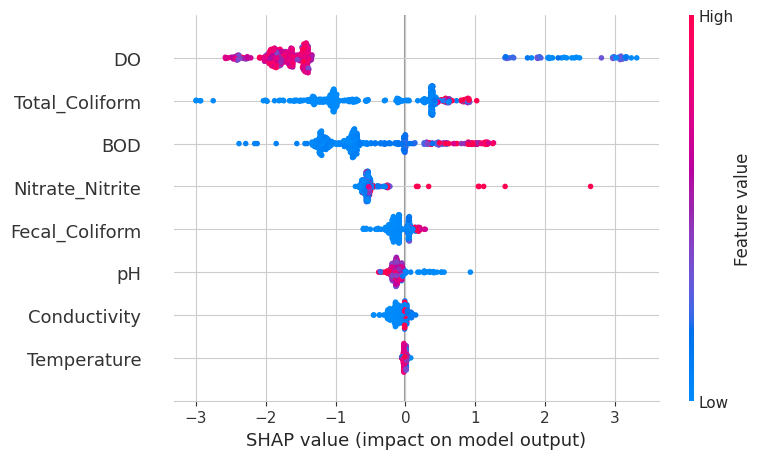

In [93]:
# SHAP summary plot for the Poor water-quality class

poor_idx = list(label_encoder.classes_).index('Poor')

# Extract SHAP values for the Poor class
shap_values_poor = shap_values[:, :, poor_idx]

# Convert test data back to a DataFrame for readable feature names
X_test_shap = pd.DataFrame(X_test_imp, columns=features)

# SHAP summary plot
shap.summary_plot(
    shap_values_poor,
    X_test_shap,
    feature_names=features
)

In [94]:
# SHAP explanation for one test sample

sample_index = 0

sample_data = X_test_shap.iloc[[sample_index]]

# Get SHAP values for the predicted class
sample_prediction_encoded = xgb_model.predict(
    sample_data.values
)[0]

sample_prediction = label_encoder.inverse_transform(
    [sample_prediction_encoded]
)[0]

predicted_class_idx = list(label_encoder.classes_).index(sample_prediction)

sample_shap_values = shap_values[
    sample_index, :, predicted_class_idx
]

print("Predicted Water Quality:", sample_prediction)
print("Class:", predicted_class_idx)

# Display feature contributions
shap_explanation = pd.DataFrame({
    'Feature': features,
    'SHAP Value': sample_shap_values,
    'Feature Value': sample_data.iloc[0].values
}).sort_values(
    by='SHAP Value',
    key=abs,
    ascending=False
)

display(shap_explanation)

Predicted Water Quality: Moderate
Class: 1


,Feature,SHAP Value,Feature Value
7,Total_Coliform,1.788803,6858.00
6,Fecal_Coliform,1.187544,3005.00
1,DO,0.224555,7.50
4,BOD,-0.209210,1.90
3,Conductivity,0.110097,211.00
5,Nitrate_Nitrite,0.092596,0.39
0,Temperature,-0.081913,22.30
2,pH,-0.078560,8.00


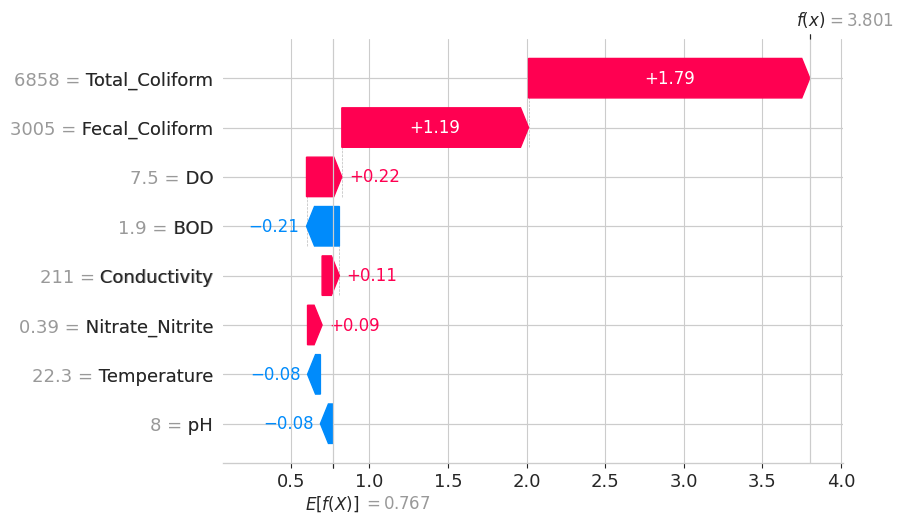

In [95]:
# Individual SHAP explanation for the predicted class

shap_values_for_sample = shap.Explanation(
    values=sample_shap_values,
    base_values=explainer.expected_value[predicted_class_idx],
    data=sample_data.iloc[0].values,
    feature_names=features
)

shap.plots.waterfall(shap_values_for_sample, max_display=8)

In [97]:
import joblib

# Save trained model
joblib.dump(xgb_model, 'xgb_model.pkl')

# Save preprocessing objects
joblib.dump(imputer, 'imputer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

# Save feature names
joblib.dump(features, 'features.pkl')

# Save cleaned dataset
df.to_csv('water_quality_cleaned.csv', index=False)

print("Model and preprocessing files saved successfully!")

Model and preprocessing files saved successfully!


In [98]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [99]:
import os

project_dir = '/content/drive/MyDrive/Water_Pollution_Project'

os.makedirs(project_dir, exist_ok=True)

print("Project folder:", project_dir)

Project folder: /content/drive/MyDrive/Water_Pollution_Project


In [100]:
import joblib
import os

# Save trained XGBoost model
joblib.dump(
    xgb_model,
    os.path.join(project_dir, 'xgb_model.pkl')
)

# Save preprocessing objects
joblib.dump(
    imputer,
    os.path.join(project_dir, 'imputer.pkl')
)

joblib.dump(
    label_encoder,
    os.path.join(project_dir, 'label_encoder.pkl')
)

# Save feature names
joblib.dump(
    features,
    os.path.join(project_dir, 'features.pkl')
)

# Save cleaned dataset
df.to_csv(
    os.path.join(project_dir, 'water_quality_cleaned.csv'),
    index=False
)

print("All project files saved successfully!")
print("\nFiles:")
for file in os.listdir(project_dir):
    print("✓", file)

All project files saved successfully!

Files:
✓ xgb_model.pkl
✓ imputer.pkl
✓ label_encoder.pkl
✓ features.pkl
✓ water_quality_cleaned.csv


In [101]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 62.5 MB/s eta 0:00:00


In [102]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Water Quality Management",
    page_icon="💧",
    layout="wide"
)

# --------------------------------------------------
# LOAD MODEL FILES
# --------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Water_Pollution_Project"

model = joblib.load(os.path.join(PROJECT_DIR, "xgb_model.pkl"))
imputer = joblib.load(os.path.join(PROJECT_DIR, "imputer.pkl"))
label_encoder = joblib.load(os.path.join(PROJECT_DIR, "label_encoder.pkl"))
features = joblib.load(os.path.join(PROJECT_DIR, "features.pkl"))

# --------------------------------------------------
# PAGE TITLE
# --------------------------------------------------

st.title("💧 AI-Based Water Quality Management System")
st.markdown(
    "### Machine Learning Based Water Quality Classification using XGBoost"
)

st.info(
    "This application classifies water samples as Good, Moderate, or Poor "
    "using the trained XGBoost model."
)

st.divider()

# --------------------------------------------------
# INPUT SECTION
# --------------------------------------------------

st.subheader("🔬 Enter Water Quality Parameters")

col1, col2 = st.columns(2)

with col1:
    temperature = st.number_input(
        "Temperature (°C)",
        min_value=0.0,
        max_value=50.0,
        value=25.0,
        step=0.1
    )

    do = st.number_input(
        "Dissolved Oxygen (DO)",
        min_value=0.0,
        max_value=20.0,
        value=6.0,
        step=0.1
    )

    ph = st.number_input(
        "pH",
        min_value=0.0,
        max_value=14.0,
        value=7.0,
        step=0.1
    )

    conductivity = st.number_input(
        "Conductivity",
        min_value=0.0,
        value=400.0,
        step=10.0
    )

with col2:
    bod = st.number_input(
        "BOD",
        min_value=0.0,
        value=2.0,
        step=0.1
    )

    nitrate_nitrite = st.number_input(
        "Nitrate/Nitrite",
        min_value=0.0,
        value=3.0,
        step=0.1
    )

    fecal_coliform = st.number_input(
        "Fecal Coliform",
        min_value=0.0,
        value=20.0,
        step=1.0
    )

    total_coliform = st.number_input(
        "Total Coliform",
        min_value=0.0,
        value=100.0,
        step=1.0
    )

st.divider()

# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

if st.button("🔍 Analyze Water Quality", type="primary"):

    sample = pd.DataFrame([[
        temperature,
        do,
        ph,
        conductivity,
        bod,
        nitrate_nitrite,
        fecal_coliform,
        total_coliform
    ]], columns=features)

    # Apply same preprocessing used during training
    sample_imp = imputer.transform(sample)

    # Prediction
    prediction_encoded = model.predict(sample_imp)[0]
    prediction = label_encoder.inverse_transform(
        [prediction_encoded]
    )[0]

    # Probability
    probabilities = model.predict_proba(sample_imp)[0]

    probability_dict = dict(
        zip(label_encoder.classes_, probabilities)
    )

    # --------------------------------------------------
    # RESULT
    # --------------------------------------------------

    st.subheader("📊 Prediction Result")

    result_col1, result_col2 = st.columns(2)

    with result_col1:

        if prediction == "Good":
            st.success(f"### Water Quality: {prediction}")

        elif prediction == "Moderate":
            st.warning(f"### Water Quality: {prediction}")

        else:
            st.error(f"### Water Quality: {prediction}")

    with result_col2:

        confidence = probability_dict[prediction] * 100

        st.metric(
            "Model Confidence",
            f"{confidence:.2f}%"
        )

    # --------------------------------------------------
    # PROBABILITIES
    # --------------------------------------------------

    st.subheader("📈 Class Probabilities")

    probability_df = pd.DataFrame({
        "Water Quality": probability_dict.keys(),
        "Probability": [
            f"{value * 100:.2f}%"
            for value in probability_dict.values()
        ]
    })

    st.dataframe(
        probability_df,
        use_container_width=True,
        hide_index=True
    )

    # --------------------------------------------------
    # MANAGEMENT RECOMMENDATIONS
    # --------------------------------------------------

    st.subheader("🛠️ Water Management Recommendations")

    recommendations = []

    if bod > 3:
        recommendations.append(
            "Biological treatment / aeration to reduce organic pollution."
        )

    if do < 5:
        recommendations.append(
            "Aeration to improve dissolved oxygen."
        )

    if ph < 6.5 or ph > 8.5:
        recommendations.append(
            "pH adjustment / neutralization."
        )

    if fecal_coliform > 100:
        recommendations.append(
            "Disinfection / chlorination to control microbial contamination."
        )

    if total_coliform > 500:
        recommendations.append(
            "Filtration and disinfection."
        )

    if nitrate_nitrite > 10:
        recommendations.append(
            "Nitrate removal treatment."
        )

    if len(recommendations) == 0:
        recommendations.append(
            "No major intervention indicated by the selected parameters."
        )

    for recommendation in recommendations:
        st.write("🔹", recommendation)

    # --------------------------------------------------
    # INPUT SUMMARY
    # --------------------------------------------------

    st.subheader("📋 Input Parameters")

    st.dataframe(
        sample,
        use_container_width=True,
        hide_index=True
    )

# --------------------------------------------------
# DISCLAIMER
# --------------------------------------------------

st.divider()

st.caption(
    "Note: The Good/Moderate/Poor classes are derived from the "
    "project's selected parameter-based scoring scheme. They should "
    "not be interpreted as official drinking-water certification."
)
'''

app_path = os.path.join(project_dir, "app.py")

with open(app_path, "w") as f:
    f.write(app_code)

print("Streamlit application created successfully!")
print(app_path)

Streamlit application created successfully!
/content/drive/MyDrive/Water_Pollution_Project/app.py


In [103]:
import subprocess
import time

# Start Streamlit in the background
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        os.path.join(project_dir, "app.py"),
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("Streamlit server started!")

Streamlit server started!
